# Evaluation of Protocloud on DCM Dataset:
* Adapted code from tutorial on [Protocloud Github](https://github.com/Ding-Group/ProtoCloud/blob/main/tutorial/tutorial.ipynb)
* evaluates protocloud on the DCM dataset in comparison to the healthy hold-out test dataset
* performs analyses and generate plots for OOD Detection, PRP analyses, etc.



# Set up

In [ ]:
!pip install -q scanpy
!pip install -q scvi-tools

In [ ]:
import scanpy as sc
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch
import umap
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Clone Protocloud Model
!git clone https://github.com/Ding-Group/ProtoCloud.git
%cd ProtoCloud

Cloning into 'ProtoCloud'...
remote: Enumerating objects: 548, done.
remote: Total 548 (delta 0), reused 0 (delta 0), pack-reused 548 (from 1)
Receiving objects: 100% (548/548), 97.27 MiB | 11.80 MiB/s, done.
Resolving deltas: 100% (267/267), done.
/content/ProtoCloud


In [ ]:
import sys
# Add the parent directory of the 'ProtoCloud' package (which is 'src') to sys.path.
# This is necessary because the actual package source is located under a 'src' directory
# within the cloned repository.
if '/content/ProtoCloud/src' not in sys.path:
    sys.path.append('/content/ProtoCloud/src')

# Change directory to ProtoCloud where main.py and pyproject.toml are located.
# This is also where 'pip install -e .' should be run from to handle dependencies.
%cd /content/ProtoCloud

# Install ProtoCloud in editable mode. This helps make the package available
# to the Python environment by correctly linking to the 'src/ProtoCloud' directory.
!pip install -e .

/content/ProtoCloud
Obtaining file:///content/ProtoCloud
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ProtoCloud (pyproject.toml) ... done
  Created wheel for ProtoCloud: filename=protocloud-1.0.0-0.editable-py3-none-any.whl size=4841 sha256=a314deb9c82544203291a0b9616d7b7f9a8330176217e8a482a16ed67d7927d1
  Stored in directory: /tmp/pip-ephem-wheel-cache-e2inppfw/wheels/32/8f/58/e5b5797deefcbf4d2c2100dd034c484e60931500e933cf6d4e
Successfully built ProtoCloud


In [ ]:
# set seeds
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
import os, shutil
import numpy as np
import pandas as pd
import torch
import ProtoCloud

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Paths
HEALTHY_DATA_DIR = '/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/'
UNHEALTHY_DATA_DIR = '/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/'

UNHEALTHY_DATA_TEST_FILE_NAME = 'DCM_test_set_1'
HEALTHY_DATA_TRAIN_FILE_NAME = 'train_set_1'
HEALTHY_DATA_VALID_FILE_NAME = 'validation_set_1'
HEALTHY_DATA_TEST_FILE_NAME = 'healthy_test_set_1'

Using device: cpu


In [ ]:
train_data = ProtoCloud.data.scRNAData(
    dataset_name=HEALTHY_DATA_TRAIN_FILE_NAME,
    data_dir=HEALTHY_DATA_DIR,
    filter_cell_by_counts = 0
)

valid_data = ProtoCloud.data.scRNAData(
    dataset_name=HEALTHY_DATA_VALID_FILE_NAME,
    data_dir=HEALTHY_DATA_DIR,
    filter_cell_by_counts=0
)

Loading outside dataset, this will not process the data
AnnData object with n_obs × n_vars = 9048 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'celltype'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ribo', 'log1p_mean_counts', 'log1p_total_counts', 'gene_name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Condition_colors', 'hvg', 'log1p', 'orig.ident_colors'


In [ ]:
train_idx, _ = train_data.get_split_idx(test_ratio=0)
_, valid_idx = valid_data.get_split_idx(test_ratio=1)

# Get the dense matrices and integer labels
train_X, _, train_Y, _ = train_data.split_data(train_idx, [], data_balance=False)
_, valid_X, _, valid_Y = valid_data.split_data([], valid_idx, data_balance=False)

train_Y_text = np.array([train_data.celltypes[i] for i in train_idx])
valid_Y_text = np.array([valid_data.celltypes[i] for i in valid_idx])


	Using adata.X as input
	Using adata.X as input


In [ ]:
# Load model architecture and weights
MODEL_DIR = "/content/drive/MyDrive/CPSC445_Project/ProtocloudModel_04012026_2/"
MODEL_DIR_HEALTHY_TRAIN = MODEL_DIR + HEALTHY_DATA_TRAIN_FILE_NAME + "/"
EXP_CODE = 'trained_model'
model = ProtoCloud.model.load_model(MODEL_DIR_HEALTHY_TRAIN, exp_code=EXP_CODE, device=device)
cell_encoder = ProtoCloud.utils.data_info_loader('cell_encoder', MODEL_DIR_HEALTHY_TRAIN)
model.eval()

Model loaded


protoCloud(
  (encoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=3000, out_features=1024, bias=False)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Linear(in_features=1024, out_features=512, bias=False)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=False)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (z_mean): Linear(in_features=256, out_features=32, bias=True)
  (z_log_var): Linear(in_features=256, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=32, out_features=512, bias=False)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(

In [ ]:
cell_encoder.classes_

array(['Endothelium', 'Fibroblasts', 'Macrophages', 'Monocytes',
       'NK_Cells', 'Pericytes', 'Smooth_Muscle', 'T_Cells'], dtype='<U13')

In [ ]:
# sanity check to see if training done correctly:
# Ensure train_X tensor is on the same device as the model
train_X_tensor = torch.tensor(train_X, dtype=torch.float32, device=device)

# Get predictions
train_pred = pd.DataFrame(ProtoCloud.model.get_predictions(model, train_X_tensor))

train_pred = ProtoCloud.utils.process_prediction_file(
    train_pred,
    cell_encoder,
    label=cell_encoder.inverse_transform(train_Y)
)
X_new = train_X

X_tensor = torch.tensor(X_new, dtype=torch.float32, device=device)
pred_df = pd.DataFrame(ProtoCloud.model.get_predictions(model, X_tensor))
pred_df['pred_label'] = cell_encoder.inverse_transform(pred_df['idx1'])

true_labels = cell_encoder.inverse_transform(train_Y)

pred_df['true_label'] = true_labels

# See # of mismatches
print(np.sum(pred_df['pred_label']!=pred_df['true_label']))

0


In [ ]:
pred_df

,prob1,prob2,idx1,idx2,sim_proto,sim_score,pred_label,true_label
0,0.999985,0.000003,1,0,4,0.828733,Fibroblasts,Fibroblasts
1,0.999972,0.000008,0,1,3,0.847402,Endothelium,Endothelium
2,0.999961,0.000009,1,3,1,0.776999,Fibroblasts,Fibroblasts
3,0.999994,0.000001,1,3,4,0.888709,Fibroblasts,Fibroblasts
4,0.999758,0.000103,0,1,2,0.741008,Endothelium,Endothelium
...,...,...,...,...,...,...,...,...
9043,0.999967,0.000010,1,0,1,0.775985,Fibroblasts,Fibroblasts
9044,0.999524,0.000104,0,2,3,0.698870,Endothelium,Endothelium
9045,0.999981,0.000006,1,3,5,0.810922,Fibroblasts,Fibroblasts
9046,0.999847,0.000040,0,1,5,0.778180,Endothelium,Endothelium


# Prepare Validation Set


In [ ]:
# Validation set predictions
val_pred = pd.DataFrame(ProtoCloud.model.get_predictions(model, torch.Tensor(valid_X)))
val_pred = ProtoCloud.utils.process_prediction_file(
    val_pred, cell_encoder,
    label=valid_Y_text,
    model_dir=MODEL_DIR_HEALTHY_TRAIN)

In [ ]:
print(val_pred.columns)

Index(['prob1', 'prob2', 'idx1', 'idx2', 'sim_proto', 'sim_score', 'certainty',
       'certainty_threshold', 'll_threshold', 'mis_pred', 'mis_anno', 'pred1',
       'pred2', 'label'],
      dtype='object')


In [ ]:
valid_label_int = cell_encoder.transform(valid_Y_text)
learned_valid = np.isin(valid_label_int, np.arange(len(cell_encoder.classes_)))

valid_input = torch.tensor(valid_X[learned_valid], dtype=torch.float32, device=device)
valid_targets = torch.tensor(valid_label_int[learned_valid], dtype=torch.long, device=device)

# get the neg log likelihoods
with torch.no_grad():
    valid_nll = model.get_log_likelihood(valid_input, target=valid_targets)

val_pred['nll'] = np.nan
val_pred.loc[learned_valid, 'nll'] = valid_nll.cpu().numpy()

print(val_pred.groupby('label')['nll'].mean().sort_values(ascending=False))

val_pred.head()

label
Endothelium      679.901123
NK_Cells         572.058993
Macrophages      559.518768
Monocytes        520.692122
Pericytes        506.285221
Smooth_Muscle    506.022862
T_Cells          500.920094
Fibroblasts      324.435609
Name: nll, dtype: float64


,prob1,prob2,idx1,idx2,sim_proto,sim_score,certainty,certainty_threshold,ll_threshold,mis_pred,mis_anno,pred1,pred2,label,nll
0,0.998336,0.000330,7,0,5,0.721796,certain,0.699534,NaN,False,False,T_Cells,Endothelium,T_Cells,373.508087
1,0.999994,0.000002,1,3,5,0.850933,certain,0.668286,NaN,False,False,Fibroblasts,Monocytes,Fibroblasts,248.985382
2,0.999334,0.000169,0,1,5,0.656359,ambiguous,0.673927,NaN,False,False,Endothelium,Fibroblasts,Endothelium,671.323792
3,0.999959,0.000010,1,3,4,0.784035,certain,0.668286,NaN,False,False,Fibroblasts,Monocytes,Fibroblasts,240.293045
4,0.999925,0.000016,1,4,3,0.743808,certain,0.668286,NaN,False,False,Fibroblasts,NK_Cells,Fibroblasts,399.100281


# Prepare Test Healthy Set

In [ ]:
# load the unhealthy dataset as a AnnData
h_file_path = HEALTHY_DATA_DIR+HEALTHY_DATA_TEST_FILE_NAME+".h5ad"
adata_healthy = sc.read_h5ad(h_file_path)
print(adata_healthy)

AnnData object with n_obs × n_vars = 1257 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'celltype'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ribo', 'log1p_mean_counts', 'log1p_total_counts', 'gene_name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Condition_colors', 'hvg', 'log1p', 'orig.ident_colors'


In [ ]:
data_healthy = ProtoCloud.data.scRNAData(dataset_name=HEALTHY_DATA_TEST_FILE_NAME, data_dir=HEALTHY_DATA_DIR)

Loading outside dataset, this will not process the data
AnnData object with n_obs × n_vars = 1257 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'celltype'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ribo', 'log1p_mean_counts', 'log1p_total_counts', 'gene_name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Condition_colors', 'hvg', 'log1p', 'orig.ident_colors'


In [ ]:
EXP_CODE = 'trained_model'
data_healthy.gene_subset(MODEL_DIR_HEALTHY_TRAIN + EXP_CODE + '.pth')
# sync encoders with training
test_X_healthy = torch.Tensor(data_healthy.to_dense(data_healthy.adata))
test_Y_healthy = data_healthy.adata.obs['celltype'].values

Use genes as:  
load saved gene names from: /content/drive/MyDrive/CPSC445_Project/ProtocloudModel_04012026_2/train_set_1
number of genes in loaded model:  3000
3000 3000
	Shared genes in loaded model: 100.00%
	Shared genes in new dataset: 100.00%
3000
(1257, 3000) 3000 3000
AnnData object with n_obs × n_vars = 1257 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'celltype'
    var: 'gene_name'
	Using adata.X as input


/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:201: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)


In [ ]:
#make prediction:
predicted_healthy = pd.DataFrame(ProtoCloud.model.get_predictions(model, test_X_healthy))
predicted_healthy = ProtoCloud.utils.process_prediction_file(
    predicted_healthy, cell_encoder,
    label=test_Y_healthy,
    model_dir=MODEL_DIR)

predicted_healthy.head()

,prob1,prob2,idx1,idx2,sim_proto,sim_score,certainty,certainty_threshold,ll_threshold,mis_pred,mis_anno,pred1,pred2,label
0,0.997018,0.000848,2,0,0,0.669254,ambiguous,0.683387,NaN,False,False,Macrophages,Endothelium,Macrophages
1,0.999995,0.000001,1,3,5,0.884588,certain,0.669959,NaN,False,False,Fibroblasts,Monocytes,Fibroblasts
2,0.999617,0.000087,5,3,3,0.768798,certain,0.668423,NaN,False,False,Pericytes,Monocytes,Pericytes
3,0.999909,0.000021,1,4,3,0.723793,certain,0.669959,NaN,False,False,Fibroblasts,NK_Cells,Fibroblasts
4,0.999988,0.000002,1,3,2,0.834801,certain,0.669959,NaN,False,False,Fibroblasts,Monocytes,Fibroblasts


In [ ]:
# Load calibrator and apply to test data
calibrator = ProtoCloud.model.simCalibration.load(MODEL_DIR_HEALTHY_TRAIN)

calibrated = calibrator.predict_proba(
    predicted_healthy['sim_score'].values,
    predicted_healthy['pred1'].values,
)

mask = np.isnan(calibrated)

if np.any(mask):
    print(f"Warning: {mask.sum()} samples not calibrated")

predicted_healthy['calibrated_certainty'] = calibrated

In [ ]:
test_Y_healthy = adata_healthy.obs['celltype'].values
test_Y_healthy = np.array(test_Y_healthy)

metrics = calibrator.evaluate_calibration(
    predicted_healthy['sim_score'].values,
    predicted_healthy['calibrated_certainty'].values,
    test_Y_healthy,
    predicted_healthy['pred1'].values,
)

Evaluation failed: Input contains NaN.


In [ ]:
predicted_healthy['mis_pred'].sum()

np.int64(13)

In [ ]:
mis_anno_stats_h = predicted_healthy.groupby('label')['mis_anno'].mean().sort_values(ascending=False)
print(mis_anno_stats_h)

label
Smooth_Muscle    0.034483
Macrophages      0.015385
Fibroblasts      0.001453
Endothelium      0.000000
Pericytes        0.000000
T_Cells          0.000000
Monocytes        0.000000
NK_Cells         0.000000
Name: mis_anno, dtype: float64


/tmp/ipykernel_2326/2504787807.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mis_anno_stats_h = predicted_healthy.groupby('label')['mis_anno'].mean().sort_values(ascending=False)


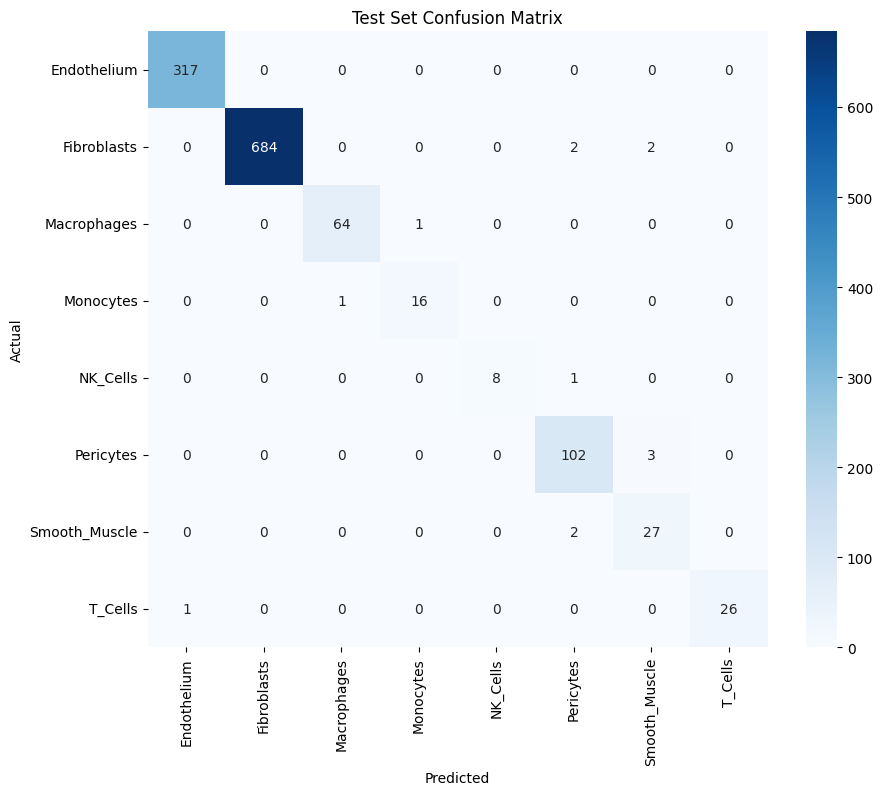

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, encoder, title="Confusion Matrix"):
    y_pred_names = encoder.inverse_transform(y_pred)

    cm = confusion_matrix(y_true, y_pred_names, labels=encoder.classes_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_,
                cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_cm(test_Y_healthy, predicted_healthy['idx1'], cell_encoder, "Test Set Confusion Matrix")

In [ ]:
#calculate NLL
healthy_label_int = cell_encoder.transform(test_Y_healthy)
learned_healthy = np.isin(healthy_label_int, np.arange(len(cell_encoder.classes_)))
healthy_input = torch.tensor(test_X_healthy[learned_healthy], dtype=torch.float32, device=device)
healthy_targets = torch.tensor(healthy_label_int[learned_healthy], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    healthy_nll = model.get_log_likelihood(healthy_input, target=healthy_targets)

predicted_healthy['nll'] = np.nan
predicted_healthy.loc[learned_healthy, 'nll'] = healthy_nll.cpu().numpy()

print(predicted_healthy.groupby('label')['nll'].mean().sort_values(ascending=False))
predicted_healthy.head()

/tmp/ipykernel_2326/949994539.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  healthy_input = torch.tensor(test_X_healthy[learned_healthy], dtype=torch.float32, device=device)


label
Endothelium      684.090891
NK_Cells         624.254445
T_Cells          525.362314
Macrophages      523.663063
Monocytes        523.583710
Pericytes        518.023307
Smooth_Muscle    514.590397
Fibroblasts      322.384316
Name: nll, dtype: float64


/tmp/ipykernel_2326/949994539.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(predicted_healthy.groupby('label')['nll'].mean().sort_values(ascending=False))


,prob1,prob2,idx1,idx2,sim_proto,sim_score,certainty,certainty_threshold,ll_threshold,mis_pred,mis_anno,pred1,pred2,label,calibrated_certainty,nll
0,0.997018,0.000848,2,0,0,0.669254,ambiguous,0.683387,NaN,False,False,Macrophages,Endothelium,Macrophages,1.0,566.723267
1,0.999995,0.000001,1,3,5,0.884588,certain,0.669959,NaN,False,False,Fibroblasts,Monocytes,Fibroblasts,1.0,223.882172
2,0.999617,0.000087,5,3,3,0.768798,certain,0.668423,NaN,False,False,Pericytes,Monocytes,Pericytes,1.0,506.762360
3,0.999909,0.000021,1,4,3,0.723793,certain,0.669959,NaN,False,False,Fibroblasts,NK_Cells,Fibroblasts,1.0,361.855896
4,0.999988,0.000002,1,3,2,0.834801,certain,0.669959,NaN,False,False,Fibroblasts,Monocytes,Fibroblasts,1.0,268.978821


# Prepare Test Unhealthy Dataset (DCM_test_set_1)

In [ ]:
# load the unhealthy dataset as a AnnData
FILE = UNHEALTHY_DATA_DIR+UNHEALTHY_DATA_TEST_FILE_NAME
file_path = f"{FILE}.h5ad"

adata_unhealthy = sc.read_h5ad(file_path)
print(adata_unhealthy)

AnnData object with n_obs × n_vars = 36621 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'celltype'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ribo', 'log1p_mean_counts', 'log1p_total_counts', 'gene_name'
    uns: 'Condition_colors', 'log1p', 'orig.ident_colors'


In [ ]:
test_data = ProtoCloud.data.scRNAData(
    dataset_name=UNHEALTHY_DATA_TEST_FILE_NAME,
    data_dir=UNHEALTHY_DATA_DIR,
    filter_cell_by_counts=0
)

_, test_idx = test_data.get_split_idx(test_ratio=1)
_, test_X, _, test_Y = test_data.split_data([], test_idx, data_balance=False)
test_Y_text  = np.array([test_data.celltypes[i] for i in test_idx])
test_Y  = cell_encoder.transform(test_Y_text)

Loading outside dataset, this will not process the data
AnnData object with n_obs × n_vars = 36621 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'celltype'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ribo', 'log1p_mean_counts', 'log1p_total_counts', 'gene_name'
    uns: 'Condition_colors', 'log1p', 'orig.ident_colors'
	Using adata.X as input


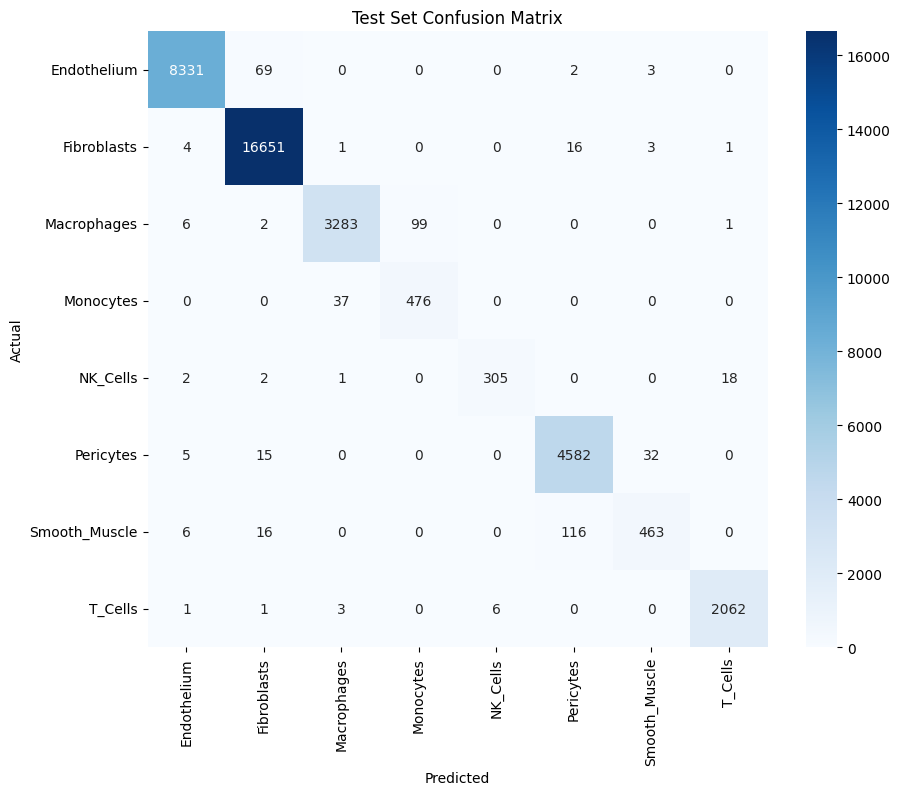

In [ ]:
test_pred = pd.DataFrame(ProtoCloud.model.get_predictions(model, torch.tensor(test_X, dtype=torch.float32, device=device)))
test_pred = ProtoCloud.utils.process_prediction_file(
    test_pred, cell_encoder,
    label=cell_encoder.inverse_transform(test_Y))

def plot_cm(y_true, y_pred, encoder, title="Confusion Matrix"):
    y_true_names = encoder.inverse_transform(y_true)
    y_pred_names = encoder.inverse_transform(y_pred)

    cm = confusion_matrix(y_true_names, y_pred_names, labels=encoder.classes_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_,
                cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_cm(test_Y, test_pred['idx1'], cell_encoder, "Test Set Confusion Matrix")

In [ ]:
# Load calibrator and apply to test data
calibrator = ProtoCloud.model.simCalibration.load(MODEL_DIR_HEALTHY_TRAIN)

test_pred['calibrated_certainty'] = calibrator.predict_proba(
    test_pred['sim_score'].values,
    test_pred['pred1'].values,
)

test_pred['calibrated_certainty'] = test_pred['calibrated_certainty'].fillna(test_pred['sim_score'])

In [ ]:
metrics = calibrator.evaluate_calibration(
    test_pred['sim_score'].values,
    test_pred['calibrated_certainty'].values,
    test_pred['label'].values,
    test_pred['pred1'].values,
)

	Original Brier Score: 0.0698, ECE: 0.2360
	Calibrated Brier Score: 0.0125, ECE: 0.0122
	Brier Improvement: 0.05730652429439668
	ECE Improvement: 0.2237985828096259


In [ ]:
test_pred['mis_pred'].sum()

np.int64(468)

In [ ]:
mis_anno_stats = test_pred.groupby('label')['mis_pred'].mean().sort_values(ascending=False)
print(mis_anno_stats)

label
Smooth_Muscle    0.229617
Monocytes        0.072125
NK_Cells         0.070122
Macrophages      0.031849
Pericytes        0.011221
Endothelium      0.008804
T_Cells          0.005306
Fibroblasts      0.001499
Name: mis_pred, dtype: float64


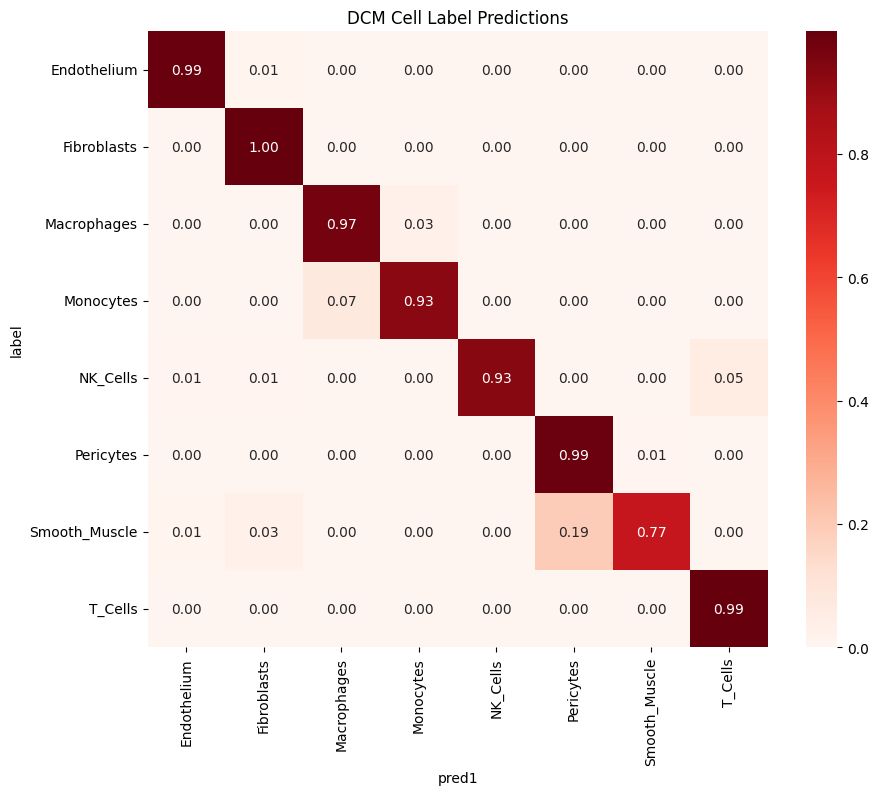

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# see confusion matrix of drifts:
confusion = test_pred.groupby(['label', 'pred1']).size().unstack(fill_value=0)

# normalize by row
confusion_pct = confusion.div(confusion.sum(axis=1), axis=0)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_pct, annot=True, cmap='Reds', fmt='.2f')
plt.title("DCM Cell Label Predictions")
plt.show()

Generate PRP Explanations for later downstream analysis...

In [ ]:
train_X.shape

(9048, 3000)

In [ ]:
model_dict = {
    'input_dim':   len(train_data.gene_names),
    'num_classes': len(train_data.cell_encoder.classes_),
    'latent_dim': 32,                 # default
    'num_prototypes_per_class': 6,    # default: number of prototypes per cell type
}
# Step 1 — Wrap the trained model with LRP rules
model_wrapped = ProtoCloud.protoCloud(**model_dict).to(device)
ProtoCloud.prp.convert_protocloud_to_lrp(
    model_wrapped, model,
    ProtoCloud.prp.lrp_params_def1,
    ProtoCloud.prp.rule_map,
)
RESULTS_DIR = "/content/drive/MyDrive/CPSC445_Project/ProtocloudResults_04012026_2/"

# Step 2 — Generate PRP explanations
prp_path = RESULTS_DIR + HEALTHY_DATA_TRAIN_FILE_NAME+ "/prp/"
ProtoCloud.utils.makedir(prp_path)

checkpoint = ProtoCloud.prp.generate_PRP_explanations(
    model_wrapped, train_X, train_Y,
    train_data,
    epsilon=model.epsilon,
    num_classes=len(cell_encoder.classes_),
    prototypes_per_class=6,
    prp_path=prp_path,
    exp_code=EXP_CODE,
    pretrain_model_pth=None,
)
np.save(MODEL_DIR_HEALTHY_TRAIN + 'prototype_checkpoint.npy', checkpoint)

ProtoCloud PRP Model Conversion Complete.
Generating PRP explanations
Calculating weighted cell-type PRP scores...


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Saved Prototype AnnData to /content/drive/MyDrive/CPSC445_Project/ProtocloudResults_04012026_2/train_set_1/prp/train_set_1_prp.h5ad


In [ ]:
# prp for dcm test
dcm_results = RESULTS_DIR + UNHEALTHY_DATA_TEST_FILE_NAME
prp_save_path = dcm_results + "/prp/"
ProtoCloud.utils.makedir(prp_save_path)
checkpoint = ProtoCloud.prp.generate_PRP_explanations(
    model_wrapped,
    test_X,
    test_Y,
    train_data,
    epsilon=model.epsilon,
    num_classes=8,
    prototypes_per_class=6,
    prp_path=prp_save_path,
    exp_code='dcm_test',
    pretrain_model_pth=MODEL_DIR_HEALTHY_TRAIN + 'prototype_checkpoint.npy'
)

Generating PRP explanations
Loading previous prototype states from /content/drive/MyDrive/CPSC445_Project/ProtocloudModel_04012026_2/train_set_1
Calculating weighted cell-type PRP scores...


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Saved Prototype AnnData to /content/drive/MyDrive/CPSC445_Project/ProtocloudResults_04012026_2/DCM_test_set_1/prp/train_set_1_prp.h5ad


In [ ]:
# work around for bug with prototype with no cells:
padding_indices = []
for cls in range(len(cell_encoder.classes_)):
    idx = np.where(test_Y_healthy == cell_encoder.classes_[cls])[0][0]
    padding_indices.append(idx)

healthy_indices = np.arange(len(test_X_healthy))
safe_indices = np.unique(np.concatenate([padding_indices, healthy_indices]))

safe_X_healthy = test_X_healthy[safe_indices]
safe_Y_healthy = test_Y_healthy[safe_indices]

safe_Y_healthy_int = cell_encoder.transform(safe_Y_healthy)

checkpoint = ProtoCloud.prp.generate_PRP_explanations(
    model=model_wrapped,
    train_X=safe_X_healthy,
    train_Y=safe_Y_healthy_int,
    data=train_data,
    epsilon=model.epsilon,
    num_classes=8,
    prototypes_per_class=6,
    prp_path=prp_save_path,
    exp_code='healthy_test',
    pretrain_model_pth=None
)

Generating PRP explanations
Calculating weighted cell-type PRP scores...


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Saved Prototype AnnData to /content/drive/MyDrive/CPSC445_Project/ProtocloudResults_04012026_2/DCM_test_set_1/prp/train_set_1_prp.h5ad


In [ ]:
#generate the npy files that weren't generated from before
export_path = RESULTS_DIR + UNHEALTHY_DATA_TEST_FILE_NAME + "/prp/"
adata_prp = sc.read_h5ad(prp_save_path + f"/{train_data.dataset_name}_prp.h5ad")

# Export each cell type from the h5ad to a .npy file
for ct in adata_prp.obs['celltype'].unique():
    proto_data = adata_prp[adata_prp.obs['celltype'] == ct].X
    save_name = f"{ct}_trained_model_relgenes.npy"
    np.save(os.path.join(export_path, save_name), proto_data)


In [ ]:
# plot top gene dotplot:
dcm_results_base = RESULTS_DIR + UNHEALTHY_DATA_TEST_FILE_NAME + "/"
internal_plot_dir = os.path.join(dcm_results_base, "plots")
os.makedirs(internal_plot_dir, exist_ok=True)
ProtoCloud.viz.plot.plot_top_gene_PRP_dotplot(
    celltypes=cell_encoder.classes_,
    gene_names=train_data.gene_names,
    num_classes=8,
    prototypes_per_class=6,
    results_dir=dcm_results_base,
    exp_code='dcm_test',
    top_num_genes=10,
    celltype_specific=True,
    save_markers=False
)

Top relevant genes collected: 72
	Top rel genes PRP dotplot saved


# Anomaly Scoring using NLL


In [ ]:
test_pred

,prob1,prob2,idx1,idx2,sim_proto,sim_score,certainty,certainty_threshold,ll_threshold,mis_pred,mis_anno,pred1,pred2,label,calibrated_certainty
0,0.999968,0.000007,1,3,1,0.774336,certain,0.66342,None,False,False,Fibroblasts,Monocytes,Fibroblasts,1.0
1,0.999974,0.000007,1,0,2,0.804511,certain,0.66342,None,False,False,Fibroblasts,Endothelium,Fibroblasts,1.0
2,0.998307,0.000589,1,0,5,0.579743,ambiguous,0.66342,None,False,False,Fibroblasts,Endothelium,Fibroblasts,1.0
3,0.991520,0.004207,1,0,1,0.581408,ambiguous,0.66342,None,False,False,Fibroblasts,Endothelium,Fibroblasts,1.0
4,0.999989,0.000003,1,0,2,0.846867,certain,0.66342,None,False,False,Fibroblasts,Endothelium,Fibroblasts,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36616,0.891679,0.040004,4,0,3,0.634476,ambiguous,0.647661,None,False,False,NK_Cells,Endothelium,NK_Cells,1.0
36617,0.764871,0.155289,4,7,0,0.581554,ambiguous,0.647661,None,False,False,NK_Cells,T_Cells,NK_Cells,1.0
36618,0.938723,0.024968,4,7,3,0.682161,certain,0.647661,None,False,False,NK_Cells,T_Cells,NK_Cells,1.0
36619,0.953715,0.019095,4,2,0,0.704454,certain,0.647661,None,False,False,NK_Cells,Macrophages,NK_Cells,1.0


In [ ]:
learned_classes = set(range(len(cell_encoder.classes_)))
dcm_targets_int = cell_encoder.transform(test_Y_text)
learned = np.array([label in learned_classes for label in dcm_targets_int])
dcm_input = torch.tensor(test_X[learned], dtype=torch.float32, device=device)
dcm_targets = torch.tensor(dcm_targets_int[learned], dtype=torch.long, device=device)

model.eval()

# get the neg log likelihoods
with torch.no_grad():
    dcm_nll = model.get_log_likelihood(dcm_input, target=dcm_targets)

test_pred['nll'] = np.nan
test_pred.loc[learned, 'nll'] = dcm_nll.cpu().numpy()

print(test_pred.groupby('label')['nll'].mean().sort_values(ascending=False))

label
NK_Cells         3200.753664
Monocytes        2941.690064
T_Cells          2798.683519
Macrophages      2556.746947
Endothelium      2100.696235
Smooth_Muscle    1653.123880
Pericytes        1626.347566
Fibroblasts       838.896263
Name: nll, dtype: float64


In [ ]:
# compare the nll between healthy and dcm test sets:
dcm_nll_stats = test_pred.groupby('label')['nll'].mean()
healthy_nll_stats = predicted_healthy.groupby('label')['nll'].mean()

nll_comparison = pd.DataFrame({
    'Healthy_Mean_NLL': healthy_nll_stats,
    'DCM_Mean_NLL': dcm_nll_stats
})

# calculate fold increase in nll
nll_comparison['NLL_Delta'] = nll_comparison['DCM_Mean_NLL'] - nll_comparison['Healthy_Mean_NLL']
nll_comparison['Fold_Increase'] = nll_comparison['DCM_Mean_NLL'] / nll_comparison['Healthy_Mean_NLL']
nll_comparison = nll_comparison.sort_values(by='Fold_Increase', ascending=False)

print("--- NLL between Healthy vs. DCM ---")
print(nll_comparison.round(2))
nll_comparison.to_csv("nll_comparison.csv")

--- NLL between Healthy vs. DCM ---
               Healthy_Mean_NLL  DCM_Mean_NLL  NLL_Delta  Fold_Increase
label                                                                  
Monocytes                523.58       2941.69    2418.11           5.62
T_Cells                  525.36       2798.68    2273.32           5.33
NK_Cells                 624.25       3200.75    2576.50           5.13
Macrophages              523.66       2556.75    2033.08           4.88
Smooth_Muscle            514.59       1653.12    1138.53           3.21
Pericytes                518.02       1626.35    1108.32           3.14
Endothelium              684.09       2100.70    1416.61           3.07
Fibroblasts              322.38        838.90     516.51           2.60


/tmp/ipykernel_2326/3519603880.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  healthy_nll_stats = predicted_healthy.groupby('label')['nll'].mean()


/tmp/ipykernel_2326/3535334231.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', len(cell_types))


UMAP computed


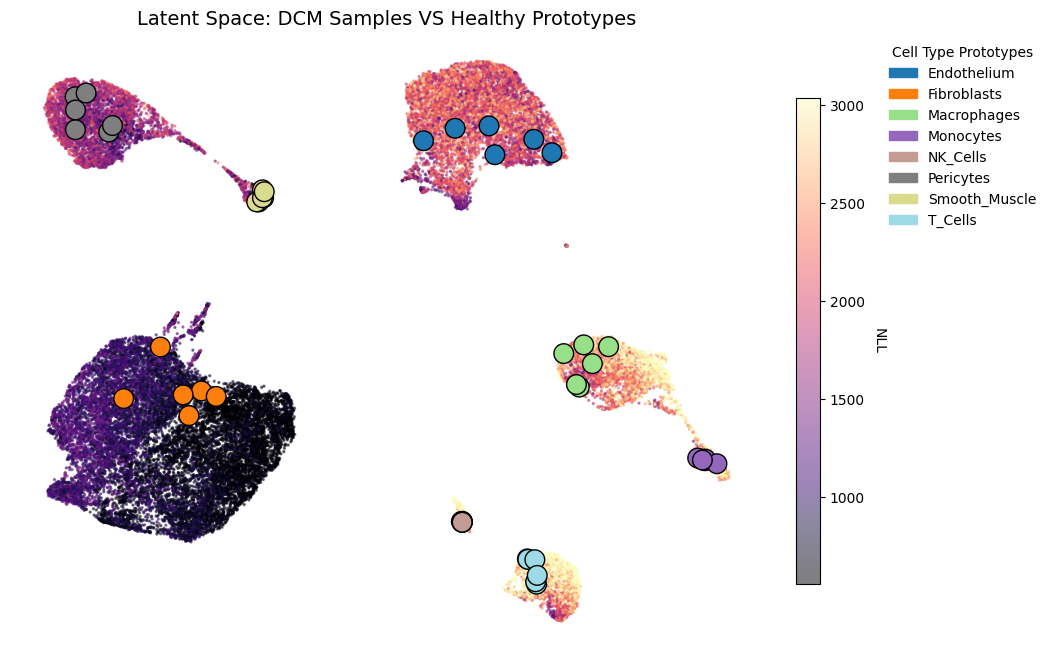

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
# plot prototypes based on NLL with DCM dataset
cell_types = np.unique(cell_encoder.classes_)
palette = plt.cm.get_cmap('tab20', len(cell_types))
colors = {t: palette(i) for i, t in enumerate(cell_types)}

# mask first
valid_mask = ~np.isnan(test_pred['nll'].values)

filtered_X = test_X[valid_mask]
anomaly_scores_np = test_pred.loc[valid_mask, 'nll'].values

# embeddings
with torch.no_grad():
    z_cells = model_wrapped.encoder(torch.Tensor(filtered_X).to(device))
    z_cells = model_wrapped.z_mean(z_cells).cpu().numpy()
    z_protos = model_wrapped.prototype_vectors.cpu().numpy()

# UMAP
combined_latent = np.vstack([z_cells, z_protos])
all_embeddings = ProtoCloud.viz.plot.get_UMAP(combined_latent, n_neighbors=15, min_dist=0.1)

num_protos = z_protos.shape[0]
cells_umap = all_embeddings[:-num_protos]
protos_umap = all_embeddings[-num_protos:]

fig, ax = plt.subplots(figsize=(12, 8))

# plot cells via scores

norm = Normalize(
    vmin=np.percentile(anomaly_scores_np, 5),
    vmax=np.percentile(anomaly_scores_np, 95)
)
scatter = ax.scatter(
    cells_umap[:, 0], cells_umap[:, 1],
    c=anomaly_scores_np, cmap='magma',
    norm=norm,
    s=2, alpha=0.5, rasterized=True
)
# get prototypes
ProtoCloud.viz.plot.plot_protos_umap(
    protos_umap, cell_types, type_color=colors,
    prototypes_per_class=6, ax=ax, s=200, a=1.0
)

#plot:
legend_handles = [mpatches.Circle((0, 0), radius=1, color=colors.get(name, 'gray'), label=name)
                  for name in cell_types]
ax.legend(handles=legend_handles, title="Cell Type Prototypes",
          bbox_to_anchor=(1.15, 1), loc='upper left', frameon=False)
cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('NLL', rotation=270, labelpad=15)
ax.set_title("Latent Space: DCM Samples VS Healthy Prototypes", fontsize=14)
ax.axis('off')
plt.subplots_adjust(right=0.8)
plt.savefig(os.path.join(dcm_results_base, "plots", "fixed_labeled_umap.png"),
            dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2326/2100588919.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', len(cell_types))


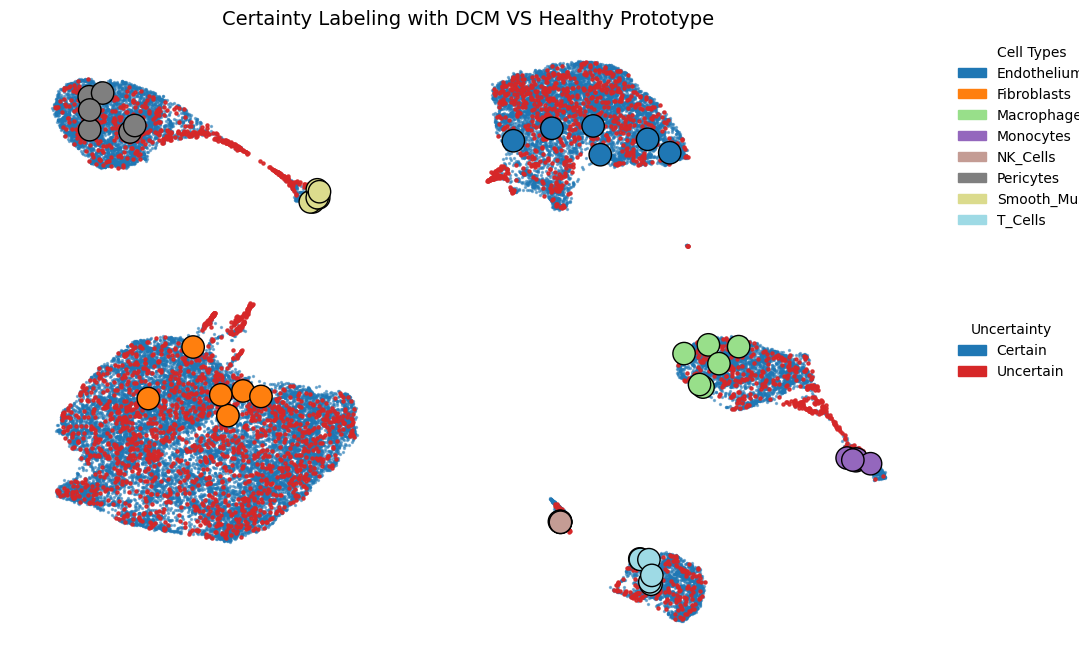

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
# plot prototypes based on similarity score
cell_types = np.unique(cell_encoder.classes_)
palette = plt.cm.get_cmap('tab20', len(cell_types))
colors = {t: palette(i) for i, t in enumerate(cell_types)}

certainty_clean = test_pred['certainty'].astype(str).str.strip().str.lower()
is_certain = (certainty_clean == 'certain').values
is_ambiguous = (certainty_clean == 'ambiguous').values

ax.scatter(cells_umap[is_certain, 0], cells_umap[is_certain, 1],
           c='#1f77b4', s=2, alpha=0.5, edgecolors=None, rasterized=True)

ax.scatter(cells_umap[is_ambiguous, 0], cells_umap[is_ambiguous, 1],
           c='#d62728', s=5, alpha=0.9, edgecolors=None, rasterized=True)

ProtoCloud.viz.plot.plot_protos_umap(
    protos_umap, cell_types,
    type_color=colors,
    prototypes_per_class=6,
    ax=ax, s=260, a=1.0
)
import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Circle((0, 0), radius=1,
                    color=colors.get(name, 'gray'),
                    label=name)
    for name in cell_types
]

legend_celltypes = ax.legend(
    handles=legend_handles,
    title="Cell Types",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

certain_patch = mpatches.Patch(color='#1f77b4', label='Certain')
uncertain_patch = mpatches.Patch(color='#d62728', label='Uncertain')

legend_certainty = ax.legend(
    handles=[certain_patch, uncertain_patch],
    title="Uncertainty",
    bbox_to_anchor=(1.02, 0.55),
    loc='upper left',
    frameon=False
)

ax.add_artist(legend_celltypes)
plt.subplots_adjust(right=0.78)

ax.set_title("Certainty Labeling with DCM VS Healthy Prototype", fontsize=14)
ax.axis('off')

plt.savefig(
    os.path.join(dcm_results_base, "plots", "similarity_label_umap.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

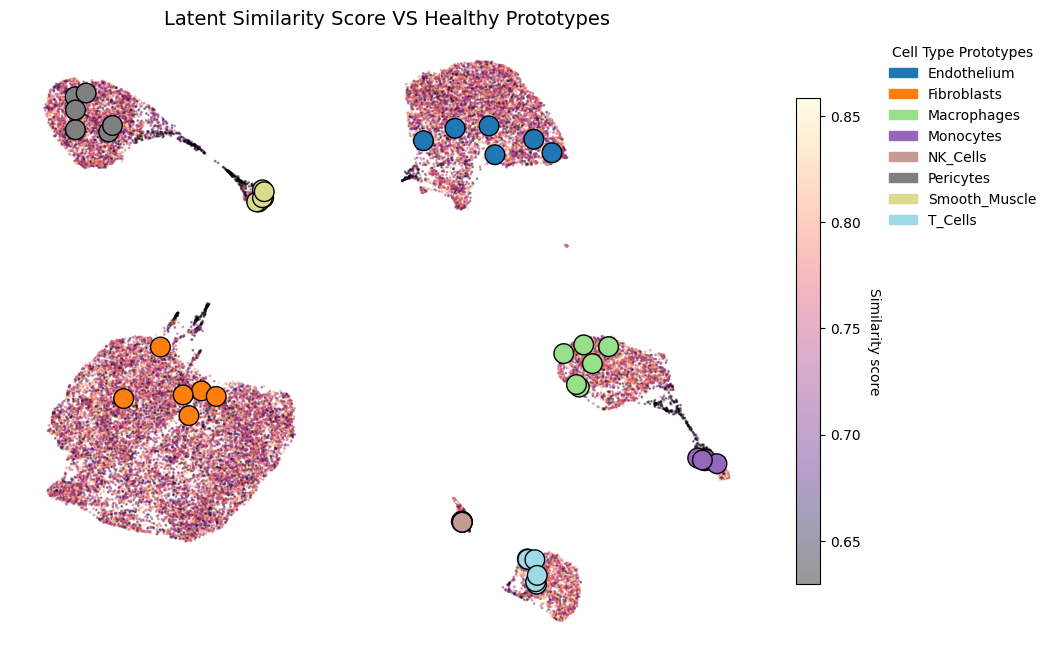

In [ ]:
from matplotlib.colors import Normalize
# plot prototypes based on sim score
mask = ~np.isnan(test_pred['nll'])

sim_scores_np = test_pred.loc[mask, 'sim_score'].values


fig, ax = plt.subplots(figsize=(12, 8))
norm = Normalize(
    vmin=np.percentile(sim_scores_np, 5),
    vmax=np.percentile(sim_scores_np, 95)
)

scatter = ax.scatter(
    cells_umap[:, 0], cells_umap[:, 1],
    c=sim_scores_np, cmap='magma',
    norm=norm,
    s=1, alpha=0.4, rasterized=True
)

# 3. Overlay your Prototypes as usual
ProtoCloud.viz.plot.plot_protos_umap(
    protos_umap, cell_types, type_color=colors,
    prototypes_per_class=6, ax=ax, s=200, a=1.0
)

#plot:
legend_handles = [mpatches.Circle((0, 0), radius=1, color=colors.get(name, 'gray'), label=name)
                  for name in cell_types]
ax.legend(handles=legend_handles, title="Cell Type Prototypes",
          bbox_to_anchor=(1.15, 1), loc='upper left', frameon=False)
cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Similarity score', rotation=270, labelpad=15)
plt.subplots_adjust(right=0.8)
ax.set_title("Latent Similarity Score VS Healthy Prototypes", fontsize=14)
ax.axis('off')
plt.savefig(os.path.join(dcm_results_base, "plots", "similarity_score_umap.png"),
            dpi=300, bbox_inches='tight')
plt.show()

# Stability Test
* perform a stability test passing the intitial prediction + reconstruction as the condition for the second pass to test model stability

In [ ]:
batch_order = np.arange(len(dcm_targets))
batch_size = 512
dataset = TensorDataset(dcm_input, dcm_targets, torch.tensor(batch_order))
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# initialize the array
final_preds_2 = np.zeros((len(dcm_targets), len(cell_encoder.classes_)))

model.eval()
with torch.no_grad():
    for batch_X, batch_y, batch_pos in loader:
        batch_X = batch_X.to(device)

        # get reconstruction predictions
        current_X = batch_X.clone()
        for i in range(2):
            recon_out = model.get_recon(current_X)
            current_X = recon_out[0] if isinstance(recon_out, tuple) else recon_out

        pred_out = model.get_pred(current_X)
        preds_2_batch = pred_out[0] if isinstance(pred_out, tuple) else pred_out

        # move predictions to CPU and store in correct order
        batch_pos = batch_pos.numpy()
        final_preds_2[batch_pos] = preds_2_batch.cpu().numpy()

initial_indices = cell_encoder.transform(test_pred.loc[learned, 'pred1'])
final_recon_pred = np.argmax(final_preds_2, axis=1)
final_pred_indices = final_recon_pred

assert len(test_pred) == len(test_X)
test_pred.loc[learned, 'pred_recon'] = cell_encoder.inverse_transform(final_pred_indices)
test_pred.loc[learned, 'label_flipped'] = (initial_indices != final_pred_indices)

In [ ]:
test_pred['pred_recon'].value_counts()

,count
pred_recon,
Fibroblasts,18227
Endothelium,18153
Pericytes,162
Macrophages,56
T_Cells,20
NK_Cells,2
Smooth_Muscle,1


In [ ]:
# see how much has drifted after the second pass test
num_flipped = test_pred['label_flipped'].sum()
print(f"identity drift after pred2: {num_flipped}")

print(f"misannotated after pred1: {test_pred['mis_anno'].sum()}")

identity drift after pred2: 24212
misannotated after pred1: 197


In [ ]:
# label them based on their results
test_pred.loc[learned, 'pred_recon'] = cell_encoder.inverse_transform(final_pred_indices)
test_pred
# count based on : flipped labels
latent_flips = test_pred[
    (test_pred['label'] == test_pred['pred1']) &
    (test_pred['label'] != test_pred['pred_recon'])
]
# recovered true label after flip
recovered = test_pred[
    (test_pred['label'] != test_pred['pred1']) &
    (test_pred['label'] == test_pred['pred_recon'])
]
# hasn't changed since first pass
stable = test_pred[
    (test_pred['label'] == test_pred['pred1']) &
    (test_pred['label'] == test_pred['pred_recon'])
]
# changed in both passes
unstable = test_pred[
    (test_pred['label'] != test_pred['pred1']) &
    (test_pred['label'] != test_pred['pred_recon'])
]

print(f"Number of Latent Identity Flips: {len(latent_flips)}, \
recovered: {len(recovered)}, stable:{len(stable)}, unstable:{len(unstable)}")

Number of Latent Identity Flips: 23804, recovered: 52, stable:12349, unstable:416


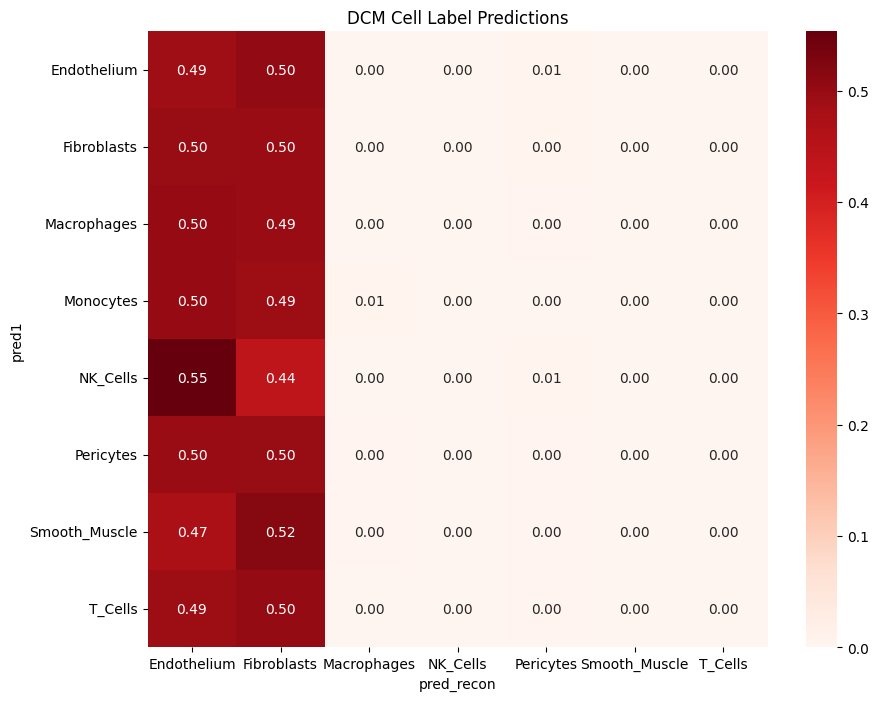

In [ ]:
# see confusion matrix of drifts in identity between the first and second pass:
confusion = test_pred.groupby(['pred1', 'pred_recon']).size().unstack(fill_value=0)

# normalize by row
confusion_pct = confusion.div(confusion.sum(axis=1), axis=0)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_pct, annot=True, cmap='Reds', fmt='.2f')
plt.title("DCM Cell Label Predictions")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# pred1
report_init = classification_report(
    test_pred.loc[learned, 'label'],
    test_pred.loc[learned, 'pred1'],
    output_dict=True,
    zero_division = 0
)
df_init = pd.DataFrame(report_init).transpose()

# pred2
report_recon = classification_report(
    test_pred.loc[learned, 'label'],
    test_pred.loc[learned, 'pred_recon'],
    output_dict=True,
    zero_division = 0
)

df_recon = pd.DataFrame(report_recon).transpose()

# compare
comparison = pd.DataFrame({
    'Initial_F1': df_init['f1-score'],
    'Recon_F1': df_recon['f1-score'],
    'Delta_F1': df_recon['f1-score'] - df_init['f1-score']
})

print(comparison.sort_values('Delta_F1'))

               Initial_F1  Recon_F1  Delta_F1
T_Cells          0.992539  0.000000 -0.992539
Macrophages      0.977665  0.002321 -0.975344
Pericytes        0.980107  0.006672 -0.973435
NK_Cells         0.954617  0.000000 -0.954617
Monocytes        0.875000  0.000000 -0.875000
macro avg        0.951310  0.099069 -0.852241
Smooth_Muscle    0.840290  0.000000 -0.840290
weighted avg     0.987101  0.287861 -0.699240
Endothelium      0.994153  0.309963 -0.684190
accuracy         0.987220  0.338631 -0.648590
Fibroblasts      0.996112  0.473598 -0.522513


Plots for stability test

/tmp/ipykernel_2326/2717544594.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_df.index, y=plot_df['Delta_F1'], palette=colors)


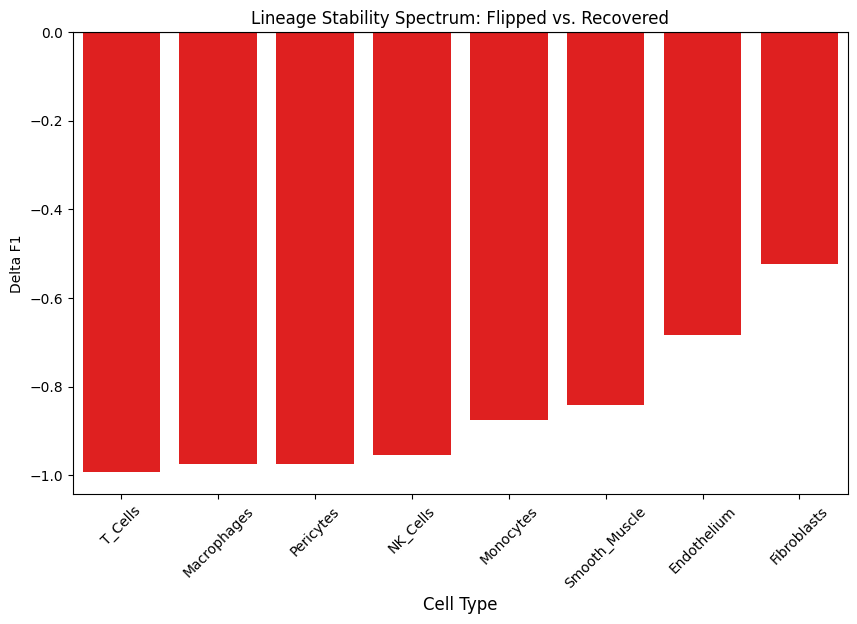

In [ ]:
# Plot the Delta F1 between the second pass and first pass results
cell_types = ['Pericytes', 'Fibroblasts', 'NK_Cells', 'Monocytes',
              'Smooth_Muscle', 'T_Cells', 'Endothelium', 'Macrophages']
plot_df = comparison.loc[cell_types].sort_values('Delta_F1')

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in plot_df['Delta_F1']]
sns.barplot(x=plot_df.index, y=plot_df['Delta_F1'], palette=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.xlabel("Cell Type", fontsize=12)
plt.title("Lineage Stability Spectrum: Flipped vs. Recovered")
plt.ylabel("Delta F1")
plt.show()

<Axes: >

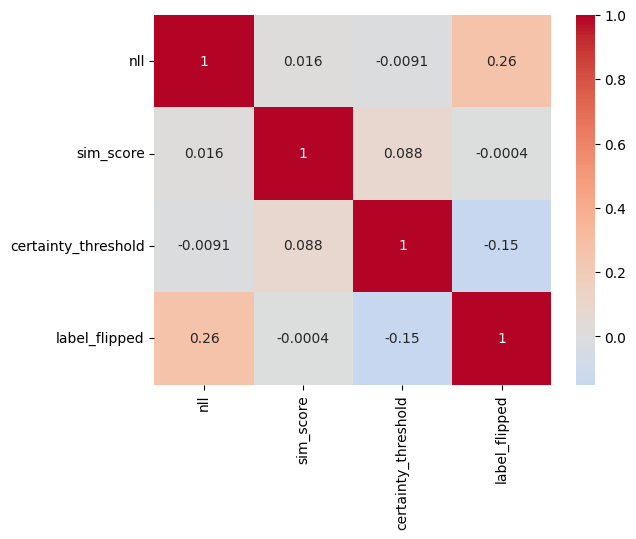

In [ ]:
# run heatmap to see correlation bewteen different criteria
plot_df = test_pred[['nll', 'sim_score', 'certainty_threshold', 'label_flipped']].copy()
plot_df = plot_df.dropna(subset=['nll'])
plot_df['label_flipped'] = plot_df['label_flipped'].astype(int)

sns.heatmap(plot_df.corr(), annot=True, cmap='coolwarm', center=0)

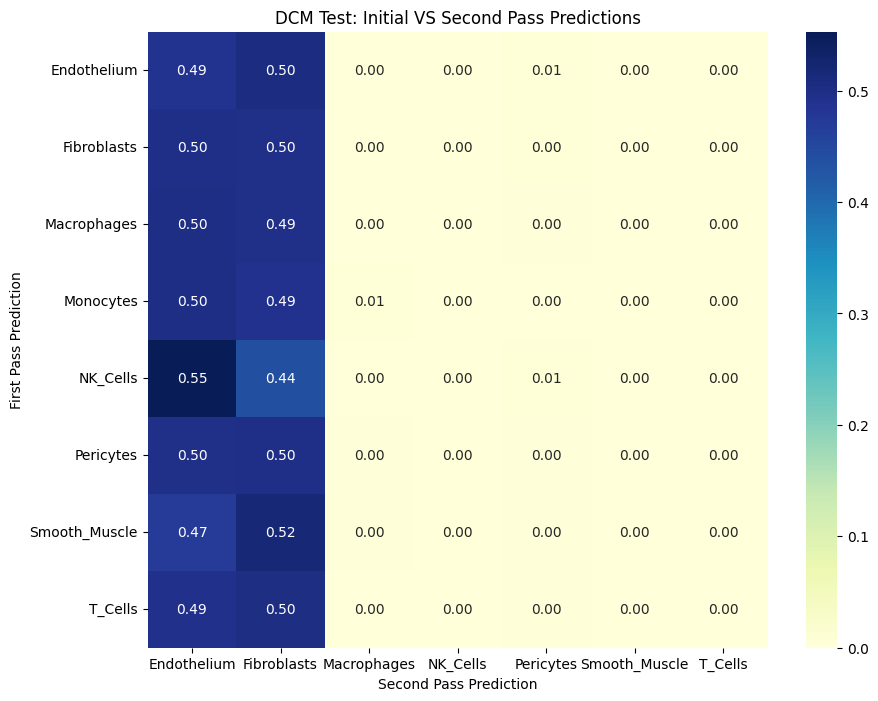

In [ ]:
# plot heatmap of initial vs second pass
final_labels_2 = cell_encoder.inverse_transform(final_pred_indices)
transitions = pd.crosstab(
    test_pred.loc[learned, 'pred1'],
    final_labels_2,
    normalize='index'
)

plt.figure(figsize=(10, 8))
sns.heatmap(transitions, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("DCM Test: Initial VS Second Pass Predictions")
plt.ylabel("First Pass Prediction")
plt.xlabel("Second Pass Prediction")
plt.show()

F1 score + global AUPRC


In [ ]:
# calculate best f1 threshold based on validation set of healhty cells:
valid_nll_np = valid_nll.cpu().numpy()
valid_labels = np.zeros(len(valid_nll_np))
best_threshold = np.percentile(valid_nll_np, 99)
print("Best threshold (99th percentile of healthy NLLs):", best_threshold)

Best threshold (99th percentile of healthy NLLs): 823.1807


In [ ]:
from sklearn.metrics import f1_score, precision_recall_curve, average_precision_score

healthy_nll_np = healthy_nll.cpu().numpy()
dcm_nll_np = dcm_nll.cpu().numpy()

# combine NLLs for evaluation
y_scores = np.concatenate([healthy_nll_np, dcm_nll_np])
y_true = np.concatenate([
    np.zeros(len(healthy_nll_np)),
    np.ones(len(dcm_nll_np))
])

# calculate F1
y_pred = (y_scores > best_threshold).astype(int)

final_f1 = f1_score(y_true, y_pred)

print("Validation NLL mean:", valid_nll_np.mean())
print("Test Healthy NLL mean:", healthy_nll_np.mean())
print(f"Deployment Threshold: {best_threshold:.2f}")
print(f"F1 at deployment threshold: {final_f1:.4f}")

Validation NLL mean: 453.9532
Test Healthy NLL mean: 454.02933
Deployment Threshold: 823.18
F1 at deployment threshold: 0.8609


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

f1_scores_thresh = f1_scores[:-1]

best_idx = np.argmax(f1_scores_thresh)
maxf1_threshold = thresholds[best_idx]
max_f1 = f1_scores_thresh[best_idx]

print(f"Max-F1: {max_f1:.4f}, Threshold: {maxf1_threshold:.4f}")

Max-F1: 0.9903, Threshold: 421.5007


AUPRC global

In [ ]:
# calculate global AUPRC for comparison with baseline models
auprc_proto = average_precision_score(y_true, y_scores)
print("AUPRC for Protocloud:", auprc_proto)

AUPRC for Protocloud: 0.9981513672532105


Comparison of AUPRC per cell type:

In [ ]:
# calculate AUPRC per cell type using NLL for cell identification
from sklearn.metrics import average_precision_score
auprc_results = []

mask = ~np.isnan(test_pred['nll'])

for cell_class in cell_types:
    y_true_binary = (test_pred.loc[mask, 'label'] == cell_class).astype(int)
    scores = test_pred.loc[mask, 'nll']

    score = average_precision_score(y_true_binary, scores)

    baseline = y_true_binary.mean()
    fold_improvement = score / baseline if baseline > 0 else np.nan

    auprc_results.append({
        'Cell Type': cell_class,
        'Count': int(y_true_binary.sum()),
        'AUPRC': round(score, 4),
        'Baseline': round(baseline, 4),
        'Fold_Improvement': round(fold_improvement, 2)
    })

auprc_df = pd.DataFrame(auprc_results).sort_values('Fold_Improvement', ascending=False)
print(auprc_df.to_string(index=False))

    Cell Type  Count  AUPRC  Baseline  Fold_Improvement
     NK_Cells    328 0.1451    0.0090             16.20
    Monocytes    513 0.0999    0.0140              7.13
      T_Cells   2073 0.3330    0.0566              5.88
  Macrophages   3391 0.3040    0.0926              3.28
  Endothelium   8405 0.3709    0.2295              1.62
    Pericytes   4634 0.1311    0.1265              1.04
Smooth_Muscle    601 0.0171    0.0164              1.04
  Fibroblasts  16676 0.2739    0.4554              0.60


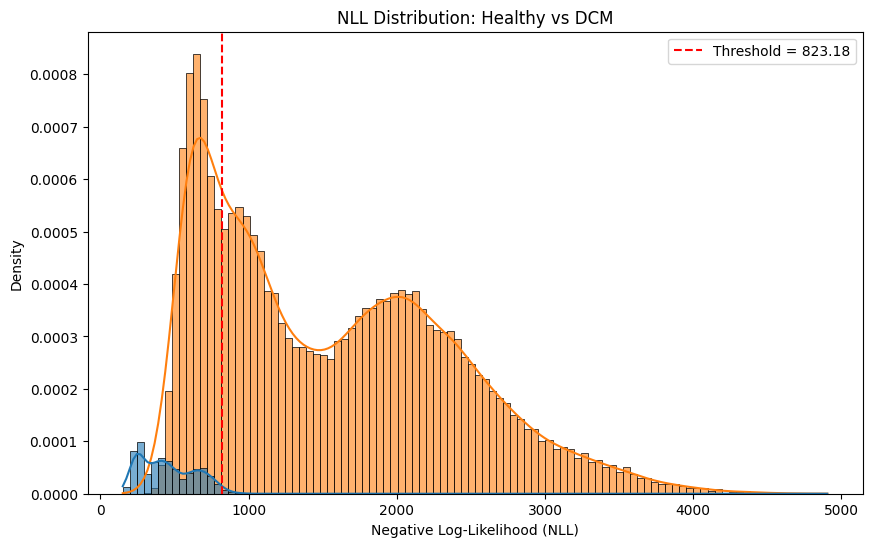

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot threshold and NLL distributions between healthy and dcm datasets
import pandas as pd
df = pd.DataFrame({
    'NLL': np.concatenate([healthy_nll_np, dcm_nll_np]),
    'Dataset': ['Healthy']*len(healthy_nll_np) + ['DCM']*len(dcm_nll_np)
})

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='NLL', hue='Dataset', bins=100, kde=True, stat='density', alpha=0.6)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Threshold = {best_threshold:.2f}')
plt.xlabel("Negative Log-Likelihood (NLL)")
plt.ylabel("Density")
plt.title("NLL Distribution: Healthy vs DCM")
plt.legend()
plt.show()

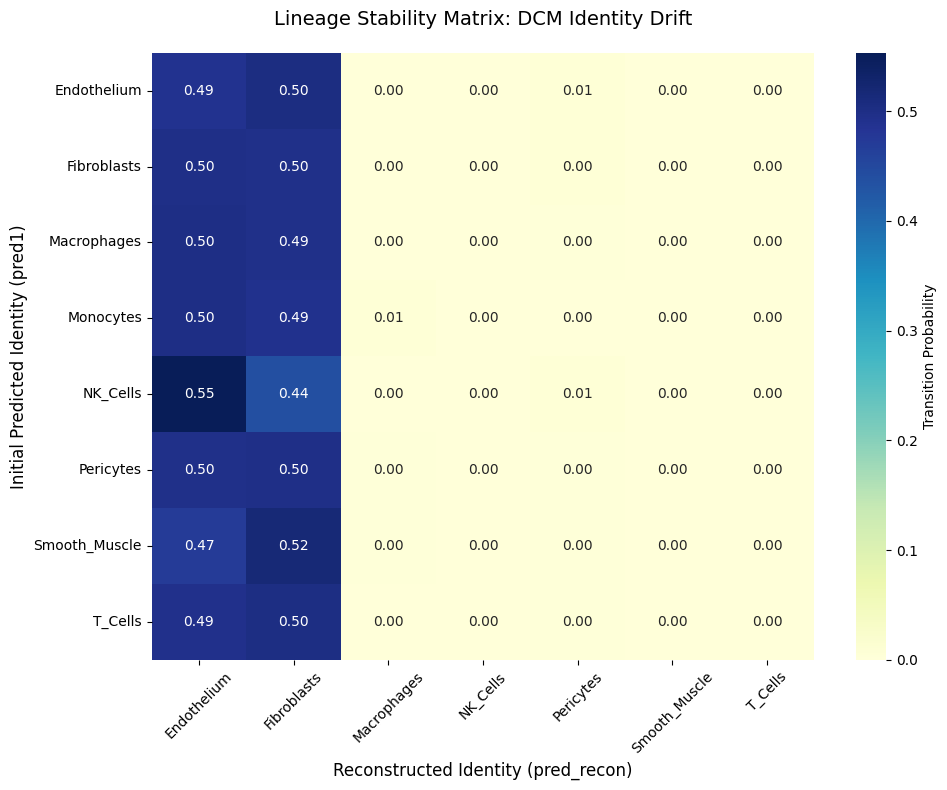

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the transition percentages in confusion matrix comparing first and second pass tests
transitions = pd.crosstab(
    test_pred.loc[learned, 'pred1'],
    test_pred.loc[learned, 'pred_recon'],
    normalize='index'
)

plt.figure(figsize=(10, 8))
sns.heatmap(transitions, annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'Transition Probability'})

plt.title("Lineage Stability Matrix: DCM Identity Drift", fontsize=14, pad=20)
plt.ylabel("Initial Predicted Identity (pred1)", fontsize=12)
plt.xlabel("Reconstructed Identity (pred_recon)", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# count labels by certainty:
counts = pd.crosstab(test_pred['label'], test_pred['certainty'])
counts['ratio_certain'] = counts['certain'] / (counts['certain'] + counts['ambiguous'])

print(counts.sort_values('ratio_certain'))

certainty      ambiguous  certain  ratio_certain
label                                           
Smooth_Muscle        123      478       0.795341
NK_Cells              47      281       0.856707
Endothelium          859     7546       0.897799
Monocytes             52      461       0.898635
Macrophages          343     3048       0.898850
T_Cells              202     1871       0.902557
Fibroblasts         1620    15056       0.902854
Pericytes            419     4215       0.909581


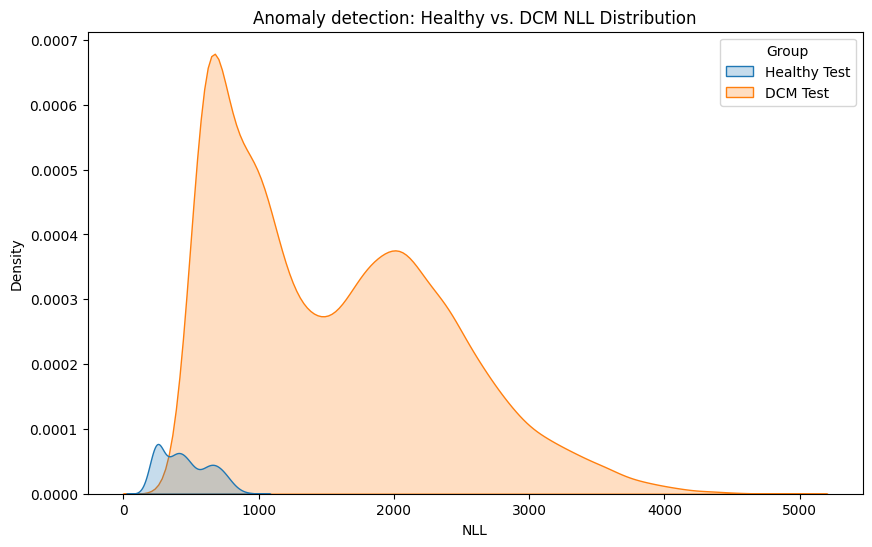

In [ ]:
comparison_df = pd.DataFrame({
    'NLL': np.concatenate([healthy_nll_np, dcm_nll_np]),
    'Group': ['Healthy Test']*len(healthy_nll_np) + ['DCM Test']*len(dcm_nll_np)
})

# Plot the distribution of NLL for healhty and dcm datasets
plt.figure(figsize=(10,6))
sns.kdeplot(data=comparison_df, x='NLL', hue='Group', fill=True)
plt.title("Anomaly detection: Healthy vs. DCM NLL Distribution")
plt.show()

# A deeper look into the minority class: NK cells

In [ ]:
outlier_NK = test_pred[(test_pred['label'] == 'NK_Cells') & (test_pred['certainty'] == 'ambiguous')]
certain_NK = test_pred[(test_pred['label'] == 'NK_Cells') & (test_pred['certainty'] == 'certain')]


healhty_NK = predicted_healthy[(predicted_healthy['label'] == 'NK_Cells')]

print(f"Mean NLL of Ambiguous NK cells: {outlier_NK['nll'].mean():.4f}")
print(f"Mean NLL of Certain NK cells: {certain_NK['nll'].mean():.4f}")
print(f"Mean NLL of Healthy NK cells: {healhty_NK['nll'].mean():.4f}")

Mean NLL of Ambiguous NK cells: 2778.6301
Mean NLL of Certain NK cells: 3271.3580
Mean NLL of Healthy NK cells: 624.2544


In [ ]:
NK_df = test_pred[test_pred['label'] == 'NK_Cells'].copy()

NK_profile = NK_df.groupby('certainty').agg({
    'nll': 'mean',
    'sim_score': 'mean',
    'label_flipped': 'mean',
    'certainty_threshold': 'first'})

print(NK_profile)

                   nll  sim_score label_flipped certainty_threshold
certainty                                                          
ambiguous  2778.630111   0.575291       0.93617            0.647661
certain    3271.357959   0.764557           1.0            0.647661


In [ ]:
# prp interpretation:
nk_h_mask = (test_Y_healthy == 'NK_Cells')
nk_dcm_mask = (test_Y_text == 'NK_Cells')

dcm_nk_rel = np.load(os.path.join(export_path, "NK_Cells_trained_model_relgenes.npy"))
mean_nk_dcm = np.mean(dcm_nk_rel, axis=0)

# compare top 5
top_nk_idx = np.argsort(mean_nk_dcm)[-5:][::-1]
top_nk_genes = [train_data.gene_names[i] for i in top_nk_idx]
print(top_nk_genes)

['GNLY', 'NKG7', 'PRF1', 'CTSW', 'CD247']


# Deeper analysis with majority class: fibroblasts

In [ ]:
outlier_fibros = test_pred[(test_pred['label'] == 'Fibroblasts') & (test_pred['certainty'] == 'ambiguous')]
certain_fibros = test_pred[(test_pred['label'] == 'Fibroblasts') & (test_pred['certainty'] == 'certain')]

print(f"Mean NLL of Ambiguous fibroblasts: {outlier_fibros['nll'].mean():.4f}")
print(f"Mean NLL of Certain fibroblasts: {certain_fibros['nll'].mean():.4f}")

fibro_df = test_pred[test_pred['label'] == 'Fibroblasts'].copy()

# group by certainty and calculate the mean for scores
fibro_profile = fibro_df.groupby('certainty').agg({
    'nll': 'mean',
    'sim_score': 'mean',
    'label_flipped': 'mean',
    'certainty_threshold': 'first'})

print(fibro_profile)

Mean NLL of Ambiguous fibroblasts: 863.8984
Mean NLL of Certain fibroblasts: 836.2061
                  nll  sim_score label_flipped certainty_threshold
certainty                                                         
ambiguous  863.898446   0.626023       0.52284             0.66342
certain    836.206071   0.765253      0.503255             0.66342


In [ ]:
fibro_flips = test_pred[test_pred['label'] == 'Fibroblasts']
print(fibro_flips.groupby(['certainty', 'pred_recon']).size().unstack(fill_value=0))

pred_recon  Endothelium  Fibroblasts  Macrophages  NK_Cells  Pericytes  \
certainty                                                                
ambiguous           826          784            1         1          8   
certain            7469         7481           22         0         72   

pred_recon  T_Cells  
certainty            
ambiguous         0  
certain          12  


Compare healthy VS DCM fibroblasts PRP

In [ ]:
# run prp for the healthy test set group
fibro_healthy_test_mask = (test_Y_healthy == 'Fibroblasts')
h_test_indices = np.where(fibro_healthy_test_mask)[0]

# padd
h_test_padding_indices = []
for cls_name in cell_encoder.classes_:
    idx = np.where(test_Y_healthy == cls_name)[0]
    if len(idx) > 0:
        h_test_padding_indices.append(idx[0])

h_test_combined_indices = np.unique(np.concatenate([h_test_indices, h_test_padding_indices]))
subset_X_h_test_padded = test_X_healthy[h_test_combined_indices]
subset_Y_h_test_padded_int = cell_encoder.transform(test_Y_healthy[h_test_combined_indices])
print(f"Total Healthy cells for PRP: {len(subset_X_h_test_padded)}")

h_test_prp_path = RESULTS_DIR + HEALTHY_DATA_TEST_FILE_NAME + "/prp_fibro_h_test/"

ProtoCloud.utils.makedir(h_test_prp_path)


ProtoCloud.prp.generate_PRP_explanations(
    model_wrapped,
    subset_X_h_test_padded,
    subset_Y_h_test_padded_int,
    train_data,
    epsilon=model.epsilon,
    num_classes=len(cell_encoder.classes_),
    prototypes_per_class=6,
    prp_path=h_test_prp_path,
    exp_code='healthy_test',
    pretrain_model_pth=MODEL_DIR_HEALTHY_TRAIN + 'prototype_checkpoint.npy'
)

Total Healthy cells for PRP: 695
Generating PRP explanations
Loading previous prototype states from /content/drive/MyDrive/CPSC445_Project/ProtocloudModel_04012026_2/train_set_1
Calculating weighted cell-type PRP scores...
Saved Prototype AnnData to /content/drive/MyDrive/CPSC445_Project/ProtocloudResults_04012026_2/healthy_test_set_1/prp_fibro_h_test/train_set_1_prp.h5ad


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


{'cell_types': array(['Endothelium', 'Fibroblasts', 'Macrophages', 'Monocytes',
        'NK_Cells', 'Pericytes', 'Smooth_Muscle', 'T_Cells'], dtype=object),
 'prp_scores': array([[[9.94560425e-04, 1.16779469e-03, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [8.82854161e-04, 1.62980543e-03, 8.94286670e-04, ...,
          0.00000000e+00, 1.37911848e-04, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [3.67834757e-04, 1.37865532e-03, 4.42768069e-04, ...,
          0.00000000e+00, 1.91426763e-04, 0.00000000e+00],
         [4.58225462e-04, 9.26500943e-04, 4.78933129e-04, ...,
          1.02134982e-05, 1.46021877e-04, 0.00000000e+00],
         [1.23810326e-03, 5.63978159e-04, 0.00000000e+00, ...,
          0.00000000e+00, 2.94985948e-04, 0.00000000e+00]],
 
        [[1.22491023e-04, 1.24807426e-04, 3.91157191e-05, ...,
          0.00000000e+00, 0.000

In [ ]:
# Load Healthy Test and DCM Outlier relevance
h_test_rel = np.load(os.path.join(h_test_prp_path, "Fibroblasts_healthy_test_relgenes.npy"))
dcm_rel = np.load(os.path.join(export_path, "Fibroblasts_dcm_test_relgenes.npy"))

mean_h_test = np.mean(h_test_rel, axis=0)
mean_dcm = np.mean(dcm_rel, axis=0)

delta_h_vs_dcm = mean_dcm - mean_h_test

top_indices = np.argsort(delta_h_vs_dcm)[-100:][::-1]
top_diff_genes = [(train_data.gene_names[i], delta_h_vs_dcm[i]) for i in top_indices]

print("Top 20 Genes Differentiating DCM Fibroblasts from Healthy Test Fibroblasts:")
for gene, score in top_diff_genes[-20:]:
    print(f"{gene}: {score:.4f}")

Top 20 Genes Differentiating DCM Fibroblasts from Healthy Test Fibroblasts:
PPIC: 0.1202
PLPP1: 0.1192
MEG3: 0.1186
COMP: 0.1178
IGF1: 0.1152
ABI3BP: 0.1136
IFI6: 0.1086
TLL2: 0.1080
NEAT1: 0.1078
ID1: 0.1056
LY6E: 0.1055
TPM2: 0.1045
HLA-B: 0.1036
MAP1B: 0.1011
SVEP1: 0.1011
NR4A1: 0.0997
MYL9: 0.0983
CPE: 0.0959
CTSB: 0.0959
RGS5: 0.0935


In [ ]:
!pip install gseapy

import gseapy as gp
# enrichr analysis of GO pathways
top_gene_names = [gene[0] for gene in top_diff_genes]
enr = gp.enrichr(gene_list=top_gene_names,
                 gene_sets=['GO_Biological_Process_2023'],
                 organism='human',
                 outdir=None) # Set outdir to a path if you want to save results
print("Top Enriched Pathways for DCM Outliers:")
print(enr.results.sort_values(by='Adjusted P-value').head(10))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 7.6 MB/s eta 0:00:00
Top Enriched Pathways for DCM Outliers:
                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   
5  GO_Biological_Process_2023   
6  GO_Biological_Process_2023   
7  GO_Biological_Process_2023   
8  GO_Biological_Process_2023   
9  GO_Biological_Process_2023   

                                                Term Overlap       P-value  \
0     Supramolecular Fiber Organization (GO:0097435)  13/316  6.201138e-09   
1       Regulation Of Apoptotic Process (GO:0042981)  18/705  1.167151e-08   
2  Regulation Of Insulin-Like Growth Factor Recep...    5/19  3.106736e-08   
3          Collagen Fibril Organization (GO:0030199)    6/42  6.087525e-08   
4  Transforming Growth Factor Beta Receptor Signa...    7/72  7.130623e-08   
5  Regulation Of Cell Population Proliferation (

In [ ]:
import time
# upregulated genes:
top_up_idx = np.argsort(delta_h_vs_dcm)[-100:][::-1]
up_genes = [train_data.gene_names[i] for i in top_up_idx]

# downregulated genes:
top_down_idx = np.argsort(delta_h_vs_dcm)[:100]
down_genes = [train_data.gene_names[i] for i in top_down_idx]
plt.show()

enr_up = gp.enrichr(gene_list=up_genes,
                    gene_sets=['GO_Biological_Process_2023'],
                    organism='human', outdir=None)
time.sleep(5)
enr_down = gp.enrichr(gene_list=down_genes,
                      gene_sets=['GO_Biological_Process_2023'],
                      organism='human', outdir=None)

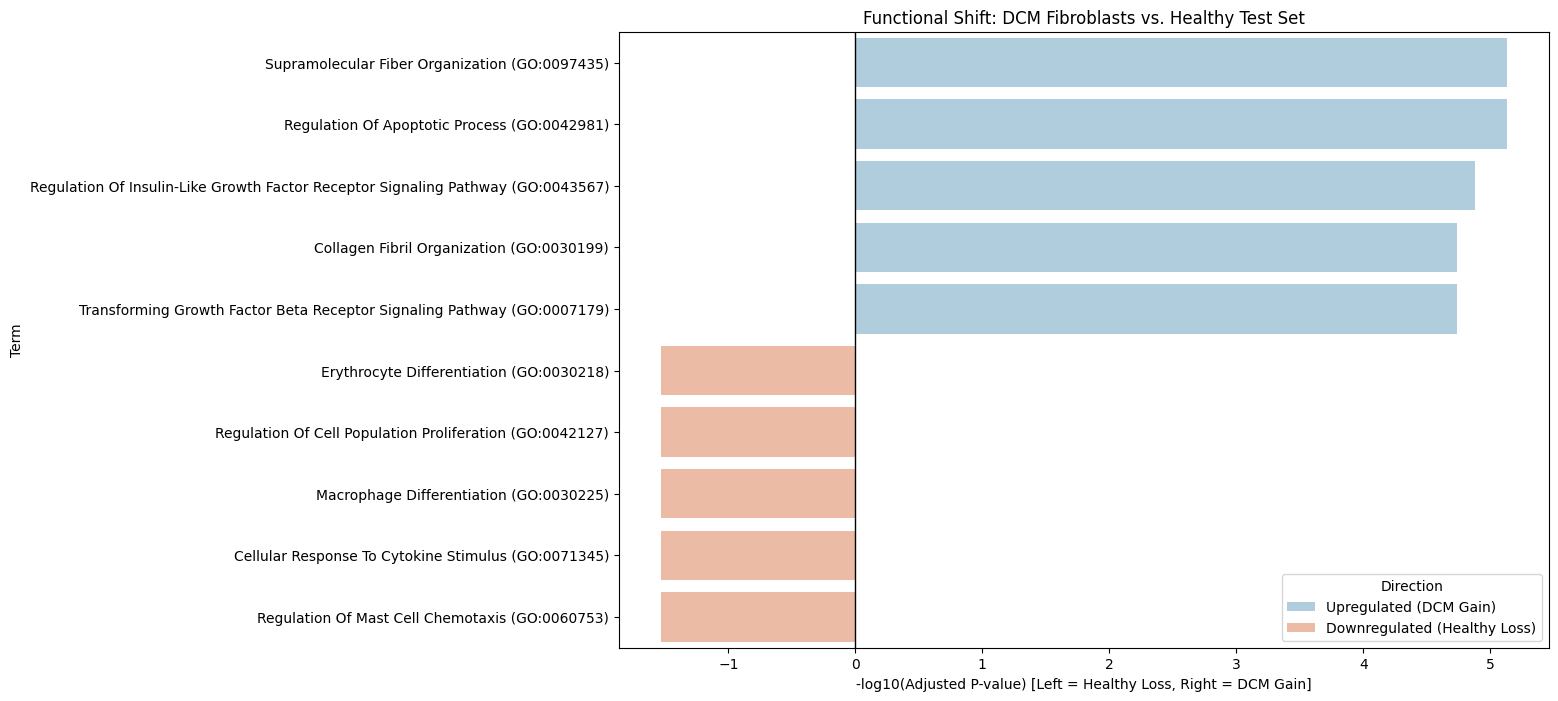

In [ ]:
# up/downreagulted GO pathways
# Get top 5 from each
up_df = enr_up.results.head(5).copy()
up_df['Direction'] = 'Upregulated (DCM Gain)'
up_df['Score'] = -np.log10(up_df['Adjusted P-value'])

down_df = enr_down.results.head(5).copy()
down_df['Direction'] = 'Downregulated (Healthy Loss)'
down_df['Score'] = -1 * (-np.log10(down_df['Adjusted P-value'])) # Make negative for plotting

# Combine and plot
viz_df = pd.concat([up_df, down_df])

plt.figure(figsize=(12, 8))
sns.barplot(data=viz_df, x='Score', y='Term', hue='Direction', palette='RdBu_r')
plt.axvline(0, color='black', linewidth=1)
plt.title("Functional Shift: DCM Fibroblasts vs. Healthy Test Set")
plt.xlabel("-log10(Adjusted P-value) [Left = Healthy Loss, Right = DCM Gain]")
plt.show()

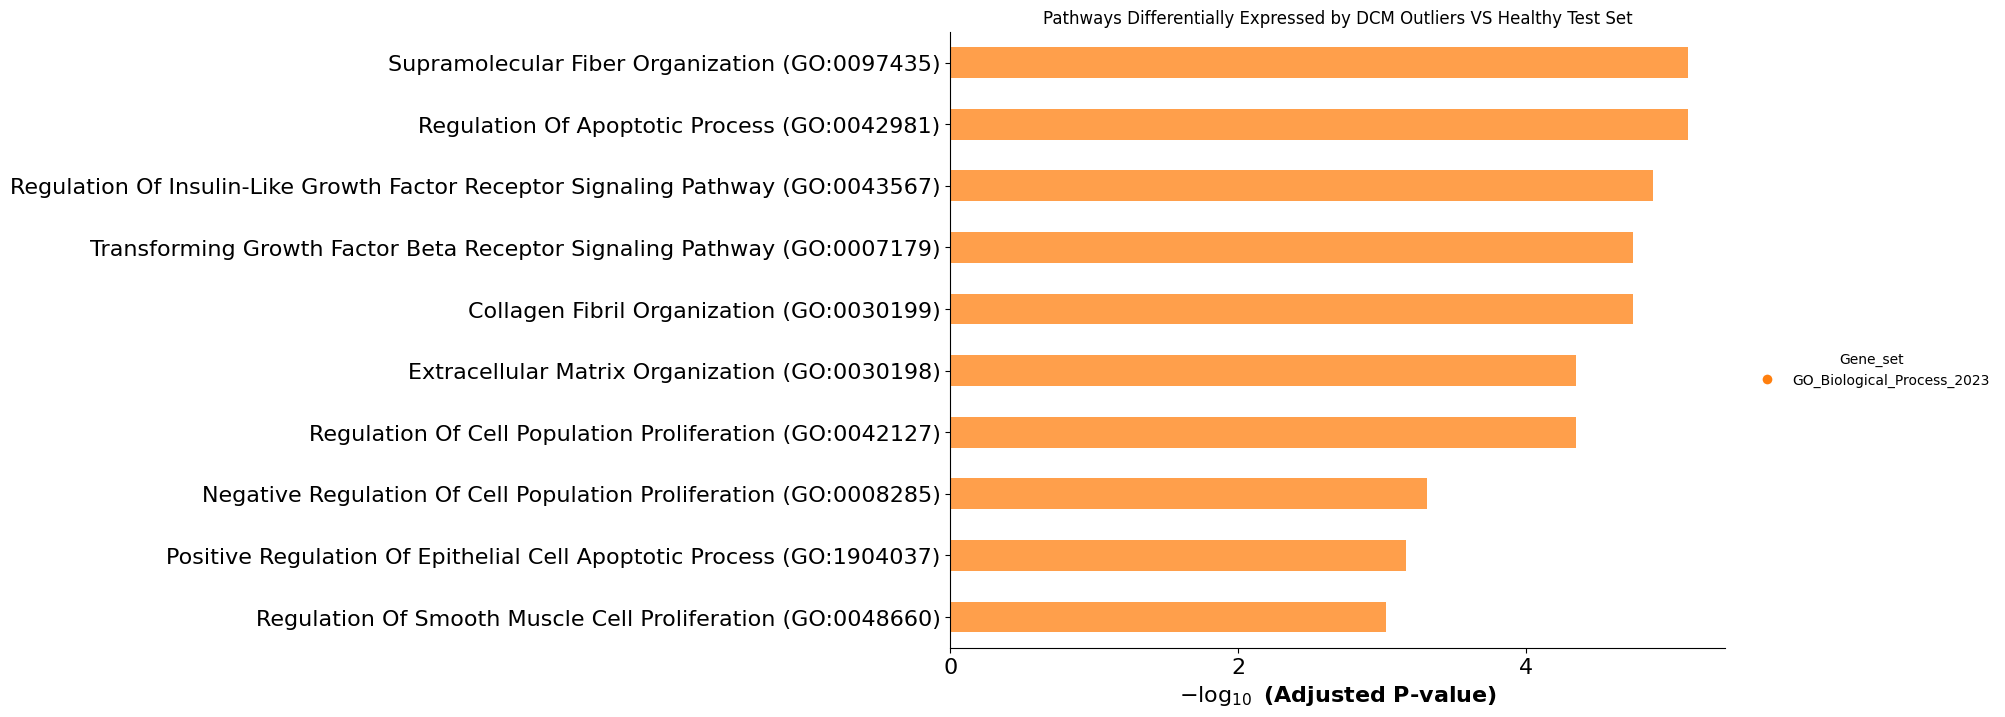

In [ ]:
delta_gene_names = [gene[0] for gene in top_diff_genes]

enr = gp.enrichr(gene_list=delta_gene_names,
                 gene_sets='GO_Biological_Process_2023',
                 organism='human',
                 outdir=None)


# barplot of most significant pathways based on padj
gp.barplot(enr.results,
           column="Adjusted P-value",
           group='Gene_set',
           size=10,
           top_term=10,
           figsize=(10, 8),
           color=['#ff7f0e', '#1f77b4'])

plt.title("Pathways Differentially Expressed by DCM Outliers VS Healthy Test Set")
plt.savefig("dcm_vs_healthy_barplot.png", bbox_inches='tight', dpi=300)
plt.show()

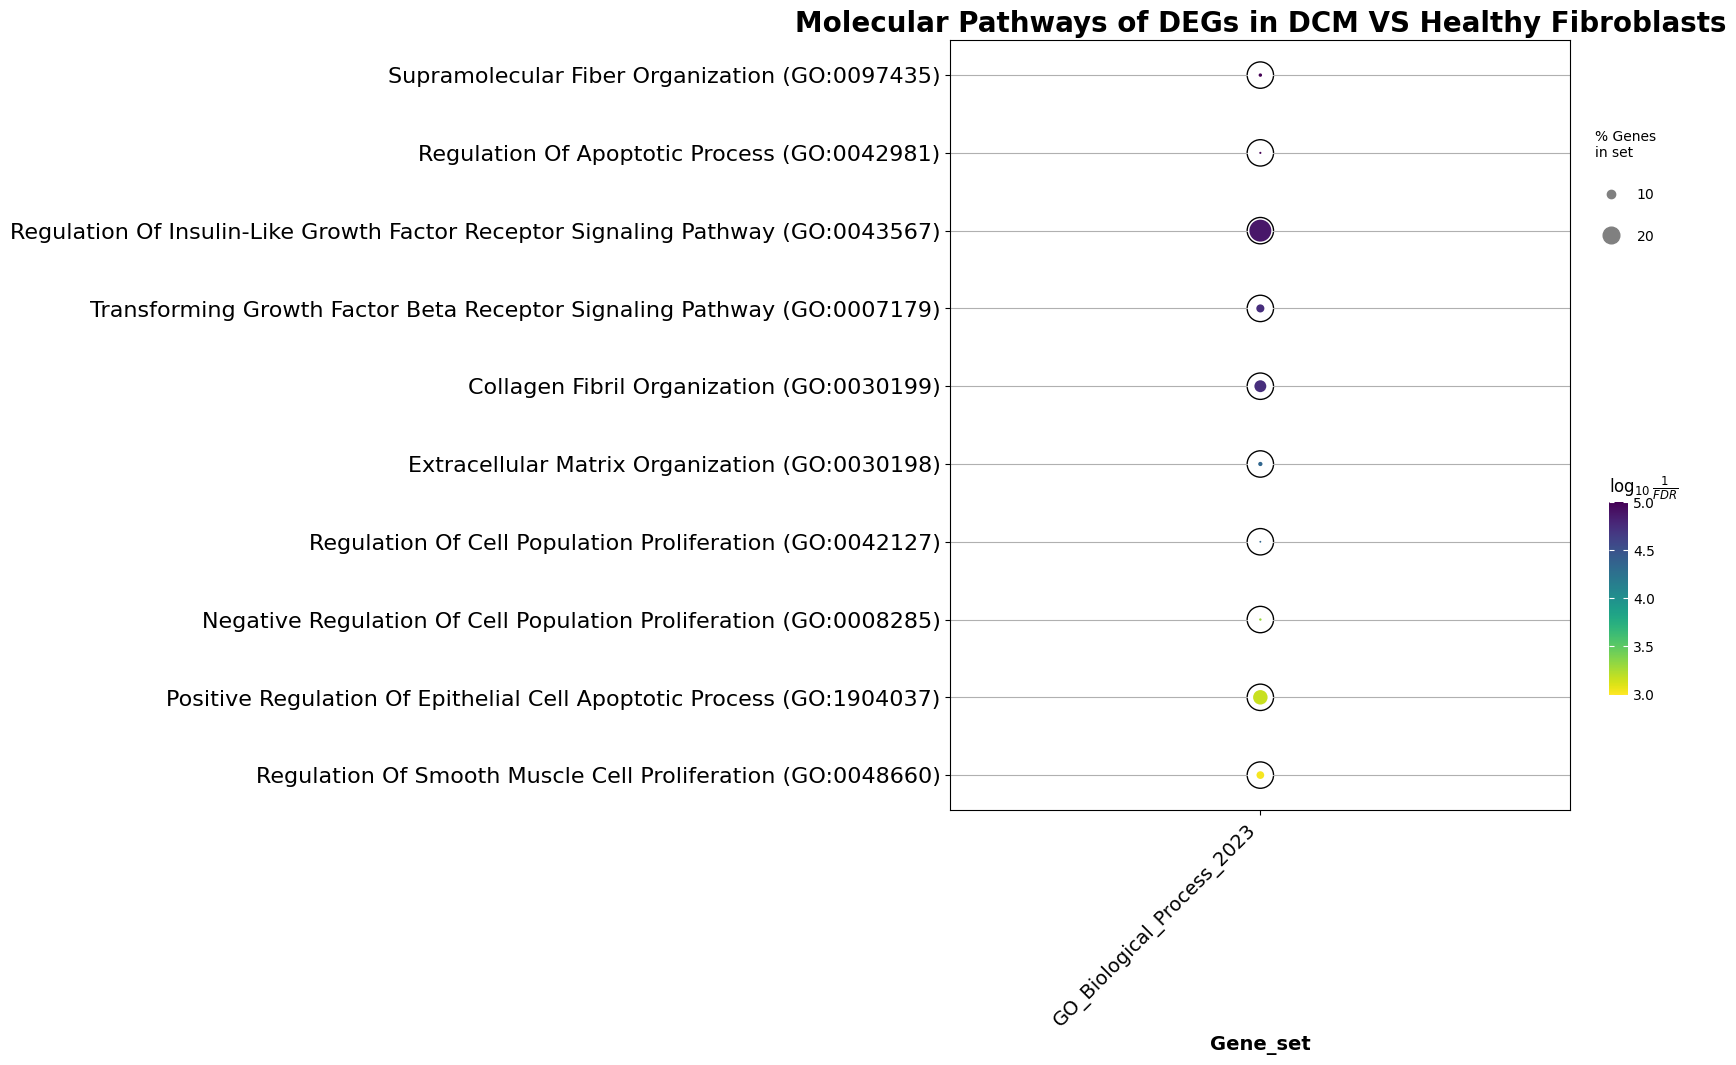

In [ ]:
# dot plot to visualize the gene + GO pathway
gp.dotplot(enr.results,
           column="Adjusted P-value",
           x='Gene_set',
           size=10,
           top_term=10,
           figsize=(10, 10),
           title="Molecular Pathways of DEGs in DCM VS Healthy Fibroblasts",
           xticklabels_rot=45,
           show_ring=True)

plt.savefig("dcm_vs_healthy_dotplot.png", bbox_inches='tight', dpi=300)
plt.show()

# Analysis of second biggest majority class Endothelium using PRP analysis:

In [ ]:
h_test_endo_file = os.path.join(h_test_prp_path, "Endothelium_healthy_test_relgenes.npy")
dcm_endo_file = os.path.join(export_path, "Endothelium_dcm_test_relgenes.npy")

h_endo_rel = np.load(h_test_endo_file)
dcm_endo_rel = np.load(dcm_endo_file)

#calculate mean relevance
mean_h_endo = np.mean(h_endo_rel, axis=0)
mean_dcm_endo = np.mean(dcm_endo_rel, axis=0)
delta_endo = mean_dcm_endo - mean_h_endo

# 4. Extract Top 20 Genes (The ones that GAIN relevance in DCM)
top_endo_idx = np.argsort(delta_endo)[-10:][::-1]
top_endo_genes = [(train_data.gene_names[i], delta_endo[i]) for i in top_endo_idx]

for gene, score in top_endo_genes:
    print(f"{gene:<15} | {score:.4f}")


CLDN5           | 0.1885
CXCL2           | 0.1425
APOLD1          | 0.0984
CYR61           | 0.0983
CCL21           | 0.0883
CDC42EP3        | 0.0877
MMRN1           | 0.0843
IGFBP3          | 0.0684
ZFP36           | 0.0573
CCL14           | 0.0572
